#Desenvolupament al nigul

##Participants: Lluis Soberats, Hector Rodríguez, Pau García & Pablo Moreno

In [31]:
# Uncomment to upgrade packages if needed
# !pip install pandas --upgrade --quiet
# !pip install numpy --upgrade --quiet
# !pip install scipy --upgrade --quiet
# !pip install scikit-learn --upgrade --quiet
# !pip install seaborn --upgrade --quiet
# !pip install matplotlib --upgrade --quiet

In [32]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from time import time
from datetime import timedelta
init_time = time()

# Laboratori 4 - Predicció de l'ús de bicicletes

El sistema de bicicletes compartides és un servei proporcionat per qualsevol ciutat important del món. L'objectiu d'aquest problema és predir quantes bicicletes s'utilitzaran diàriament cnt a partir del fitxer day.csv

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import set_config

import warnings
set_config(display='text')
warnings.filterwarnings('ignore')
sns.set()
pd.set_option('display.precision', 3)

## SECCIÓ A: Preprocessament i preparació de les dades

El primer pas és carregar les dades i eliminar variables que no siguin útils o que puguin introduir informació que no hauria d'estar disponible en la predicció:

- instant: simplement un índex de fila, no té valor predictiu
- dteday: la data en format string; la informació temporal ja està capturada per yr, mnth...
- casual i registered: són components directes de cnt (casual + registered = cnt), de manera que incloure-les seria fer trampa (data leakage)

In [34]:
# Carregar dades
df = pd.read_csv('day.csv')
print(f"Shape original: {df.shape}")
df.head()

Shape original: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344,0.364,0.806,0.160,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363,0.354,0.696,0.249,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196,0.189,0.437,0.248,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200,0.212,0.590,0.160,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.227,0.229,0.437,0.187,82,1518,1600


In [35]:
# Eliminar variables
cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
df = df.drop(columns=cols_to_drop)
print(f"Shape después de eliminar columnas: {df.shape}")
print(f"Columnas restantes: {df.columns.tolist()}")

Shape después de eliminar columnas: (731, 12)
Columnas restantes: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


In [36]:
# Separar features (X) y target (y)
X = df.drop(columns=['cnt'])
y = df['cnt']

# Divisió 60% train / 40% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 438 samples
Test size:  293 samples


### Exploració mínima del conjunt d'entrenament

Analitzem la distribució de les variables i les seves relacions amb la variable objectiu cnt

In [37]:
# Estadístiques
X_train.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
count,438.000,438.000,438.000,438.000,438.000,438.000,438.000,438.000,438.000,438.000,438.000
mean,2.516,0.518,6.596,0.027,2.986,0.658,1.397,0.505,0.484,0.637,0.188
std,1.099,0.500,3.405,0.163,2.046,0.475,0.539,0.180,0.160,0.140,0.074
min,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.059,0.079,0.000,0.022
25%,2.000,0.000,4.000,0.000,1.000,0.000,1.000,0.348,0.356,0.535,0.135
50%,3.000,1.000,7.000,0.000,3.000,1.000,1.000,0.524,0.511,0.643,0.176
75%,3.000,1.000,9.750,0.000,5.000,1.000,2.000,0.660,0.613,0.735,0.231
max,4.000,1.000,12.000,1.000,6.000,1.000,3.000,0.862,0.841,0.963,0.442


(array([ 7.,  6.,  9., 10., 15.,  9.,  9., 14., 10., 12., 16., 17., 19.,
        26., 33., 38., 28., 19., 13., 13.,  9., 17., 16., 22., 11., 18.,
        13.,  4.,  4.,  1.]),
 array([ 431. ,  707.1,  983.2, 1259.3, 1535.4, 1811.5, 2087.6, 2363.7,
        2639.8, 2915.9, 3192. , 3468.1, 3744.2, 4020.3, 4296.4, 4572.5,
        4848.6, 5124.7, 5400.8, 5676.9, 5953. , 6229.1, 6505.2, 6781.3,
        7057.4, 7333.5, 7609.6, 7885.7, 8161.8, 8437.9, 8714. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribució de cnt (Train)')

Text(0.5, 0, 'Nombre de bicicletes')

Text(0, 0.5, 'Freqüència')

{'whiskers': [<matplotlib.lines.Line2D at 0x7ba76c725970>,
 'caps': [<matplotlib.lines.Line2D at 0x7ba76c8425d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ba76c9ad730>],
 'medians': [<matplotlib.lines.Line2D at 0x7ba76c843b00>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ba76c8420c0>],
 'means': []}

Text(0.5, 1.0, 'Boxplot de cnt (Train)')

Text(0, 0.5, 'Nombre de bicicletes')

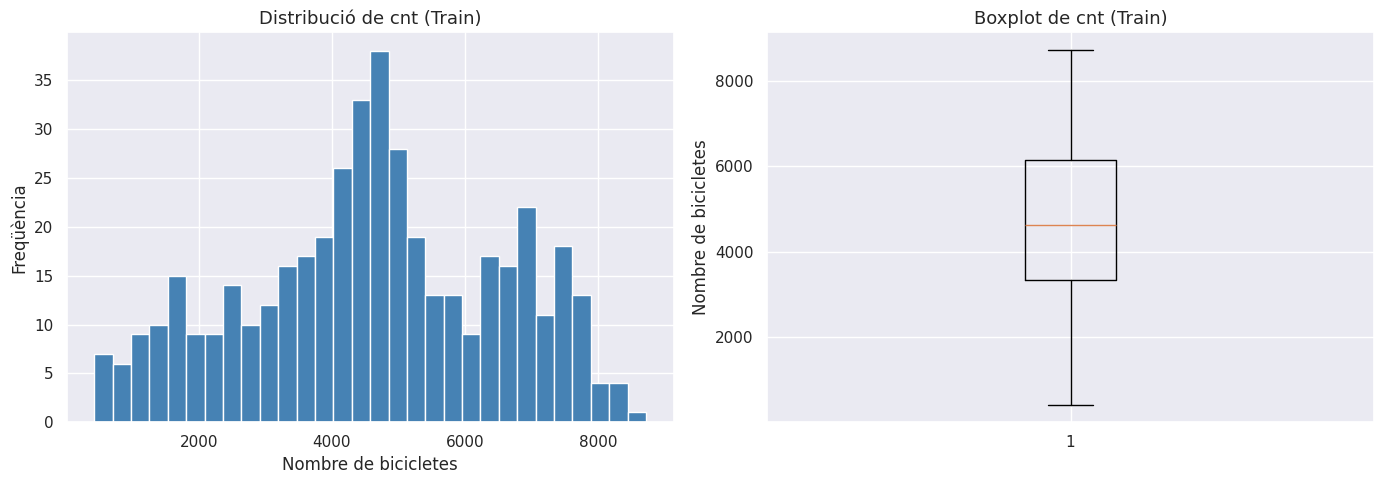

Mitjana: 4587.6  |  Mediana: 4618.5  |  Std: 1918.0


In [38]:
# Distribucció de la variable objetiu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_train, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribució de cnt (Train)', fontsize=13)
axes[0].set_xlabel('Nombre de bicicletes')
axes[0].set_ylabel('Freqüència')

axes[1].boxplot(y_train)
axes[1].set_title('Boxplot de cnt (Train)', fontsize=13)
axes[1].set_ylabel('Nombre de bicicletes')
plt.tight_layout()
plt.show()

print(f"Mitjana: {y_train.mean():.1f}  |  Mediana: {y_train.median():.1f}  |  Std: {y_train.std():.1f}")

<Figure size 1000x500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlació de cada variable amb cnt (Train)')

Text(0.5, 0, 'Correlació de Pearson')

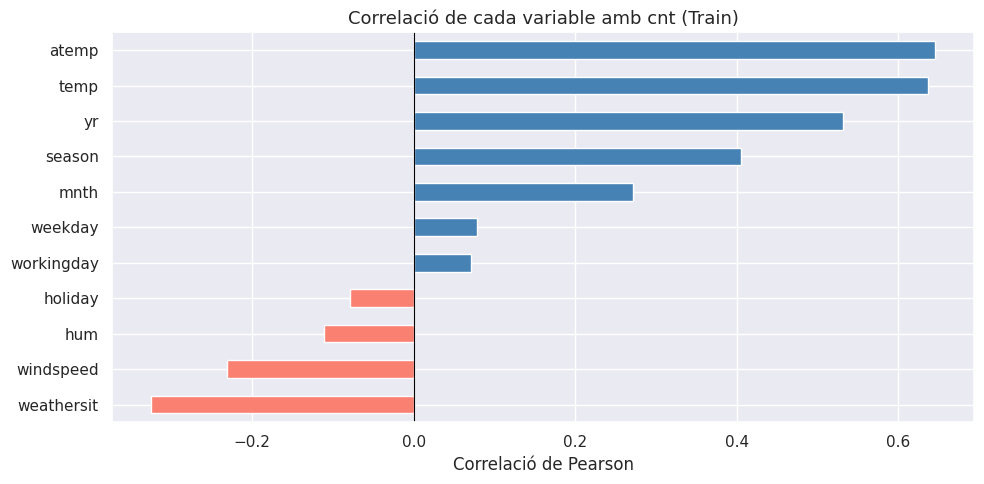

In [39]:
# Correlacció de cada feature amb cnt (train set)
train_full = X_train.copy()
train_full['cnt'] = y_train

corr_with_cnt = train_full.corr()['cnt'].drop('cnt').sort_values()

plt.figure(figsize=(10, 5))
corr_with_cnt.plot(kind='barh', color=['salmon' if c < 0 else 'steelblue' for c in corr_with_cnt])
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Correlació de cada variable amb cnt (Train)", fontsize=13)
plt.xlabel("Correlació de Pearson")
plt.tight_layout()
plt.show()

<Figure size 1200x900 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Mapa de calor de correlacions (Train)')

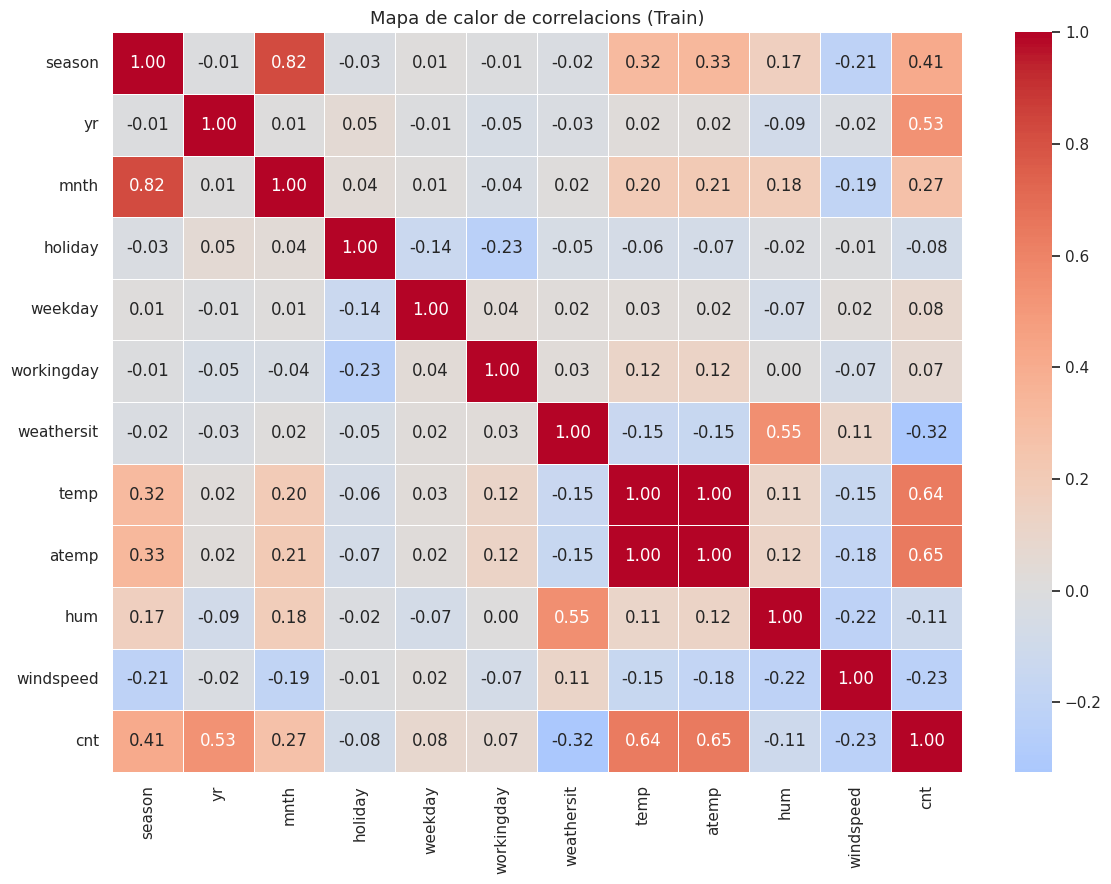

In [40]:
# Heatmap de correlacions
plt.figure(figsize=(12, 9))
sns.heatmap(train_full.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de calor de correlacions (Train)', fontsize=13)
plt.tight_layout()
plt.show()

Text(0.5, 0, 'atemp')

Text(0, 0.5, 'cnt')

Text(0.5, 1.0, 'atemp vs cnt')

Text(0.5, 0, 'temp')

Text(0, 0.5, 'cnt')

...

Text(0.5, 1.0, 'yr vs cnt')

Text(0.5, 0, 'season')

Text(0, 0.5, 'cnt')

Text(0.5, 1.0, 'season vs cnt')

Text(0.5, 1.02, 'Variables més correlacionades amb cnt')

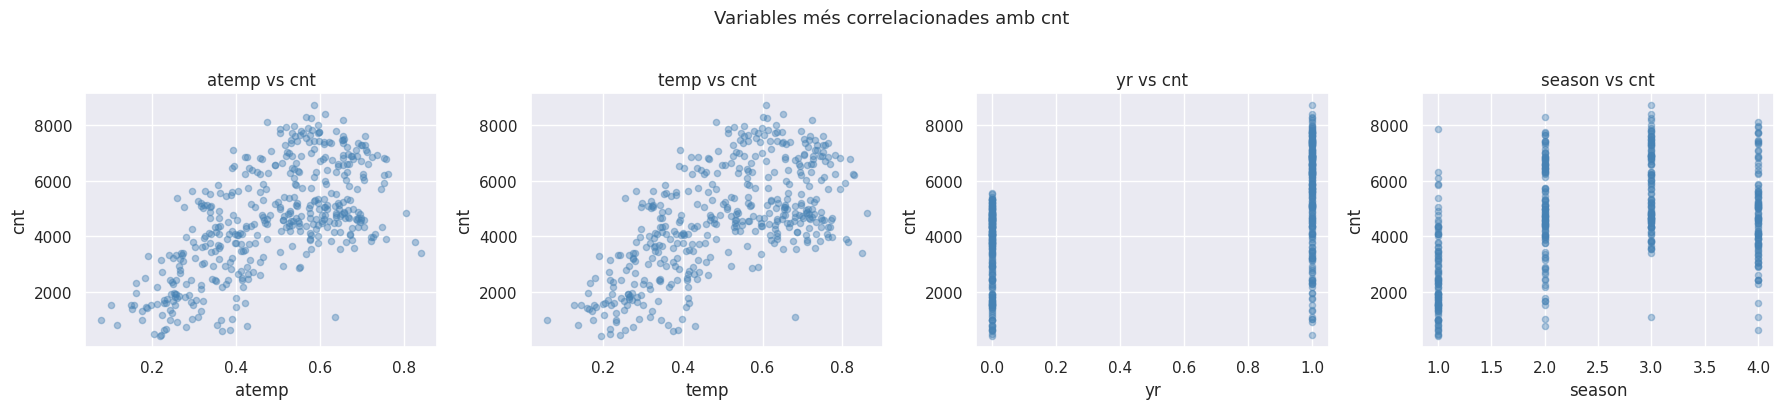

In [41]:
# Scatter plots de variables més correlacionades amb cnt
top_vars = corr_with_cnt.abs().sort_values(ascending=False).index[:4].tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, var in zip(axes, top_vars):
    ax.scatter(X_train[var], y_train, alpha=0.4, s=20, color='steelblue')
    ax.set_xlabel(var)
    ax.set_ylabel('cnt')
    ax.set_title(f'{var} vs cnt')
plt.suptitle('Variables més correlacionades amb cnt', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Observacions interessants:**
- temp i atemp (temperatura real i sensació tèrmica) estan molt correlacionades entre elles (multicolinealitat) i presenten correlació positiva forta amb cnt: a més temperatura, més ús de bicicletes
- hum (humitat) i windspeed presenten correlació negativa: condicions adverses redueixen l'ús
- yr (any) té correlació positiva notable: el sistema ha crescut any rere any
- Les variables categòriques com season i weathersit mostren diferències clares en la distribució de cnt

### Estandardització de les variables

In [42]:
# Calcular el scaler SOLO con datos de entrenamiento y aplicarlo a ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Estadísticas post-escalado (Train):")
X_train_scaled.describe().loc[['mean','std']]

Estadísticas post-escalado (Train):


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
mean,-1.399e-16,-1.622e-17,7.706e-17,-3.244e-17,-2.332e-17,9.733e-17,-4.461e-17,-2.332e-16,4.198e-16,-5.029e-16,-3.244e-17
std,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00


## SECCIÓ B: Reducció de dimensionalitat

Apliquem PCA sobre les dades d'entrenament estandarditzades per explorar l'estructura dels dades en un espai de dimensionalitat reduïda

<BarContainer object of 11 artists>

Text(0.5, 0, 'Component Principal')

Text(0, 0.5, 'Variança explicada')

Text(0.5, 1.0, 'Variança explicada per component')

Text(0.5, 0, 'Nombre de components')

Text(0, 0.5, 'Variança acumulada')

Text(0.5, 1.0, 'Variança acumulada (Scree plot)')

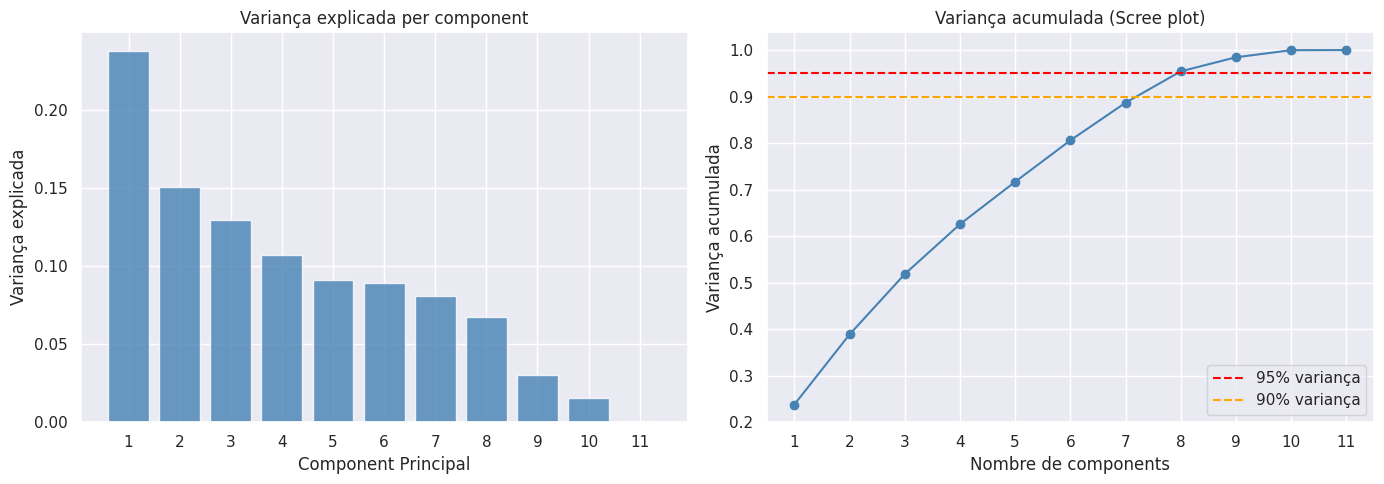

Components necessaris per explicar el 90% de la variança: 8
Components necessaris per explicar el 95% de la variança: 8


In [43]:
# PCA sobre datos de entrenamiento
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Varianza explicada
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Component Principal')
axes[0].set_ylabel('Variança explicada')
axes[0].set_title('Variança explicada per component')
axes[0].set_xticks(range(1, len(explained_var)+1))

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'o-', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% variança')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90% variança')
axes[1].set_xlabel('Nombre de components')
axes[1].set_ylabel('Variança acumulada')
axes[1].set_title('Variança acumulada (Scree plot)')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_var)+1))

plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components necessaris per explicar el 90% de la variança: {n_90}")
print(f"Components necessaris per explicar el 95% de la variança: {n_95}")

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

Text(0.5, 1.0, 'PCA 2D - colorejat per cnt')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

Text(0.5, 1.0, 'PCA 2D - colorejat per estació')

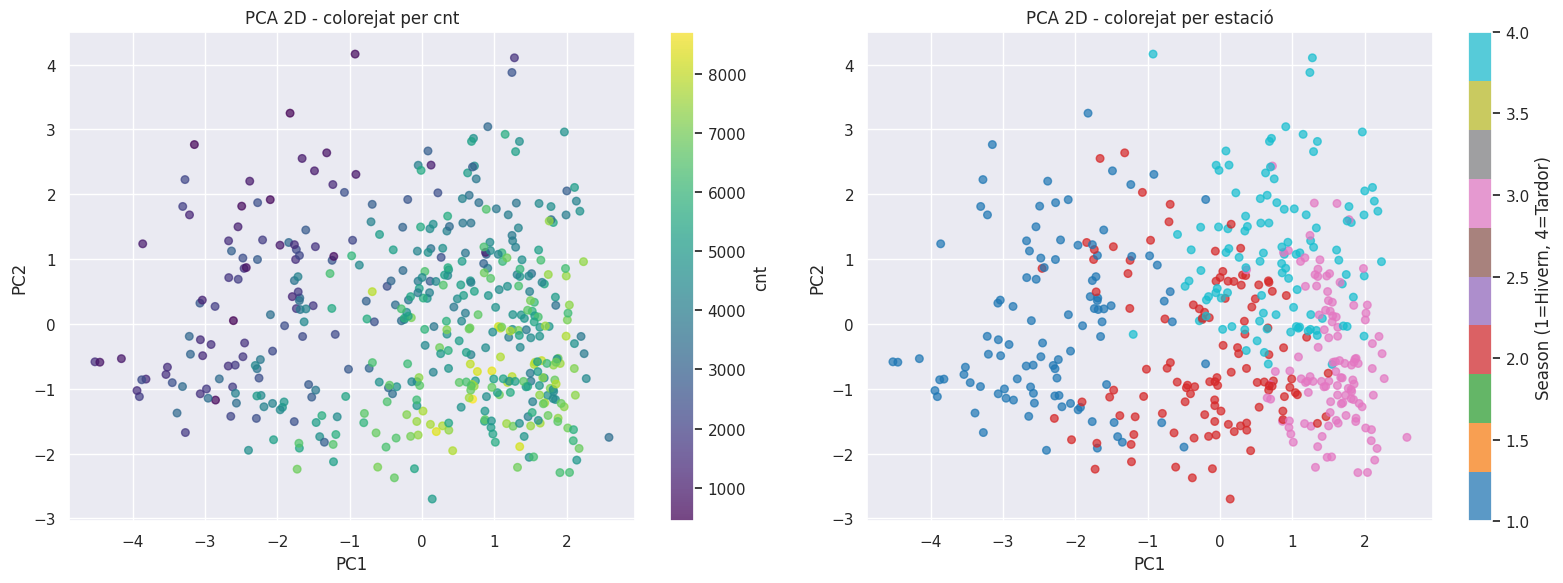

In [44]:
# Visualización 2D: primeros 2 componentes principales coloreados por cnt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                       c=y_train, cmap='viridis', alpha=0.7, s=30)
plt.colorbar(sc1, ax=axes[0], label='cnt')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA 2D - colorejat per cnt')

# Visualización 2D: coloreado por temporada
sc2 = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                       c=X_train['season'], cmap='tab10', alpha=0.7, s=30)
plt.colorbar(sc2, ax=axes[1], label='Season (1=Hivern, 4=Tardor)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA 2D - colorejat per estació')

plt.tight_layout()
plt.show()

<Axes: >

Text(0.5, 1.0, 'Contribucions de variables a PC1')

<Axes: >

Text(0.5, 1.0, 'Contribucions de variables a PC2')

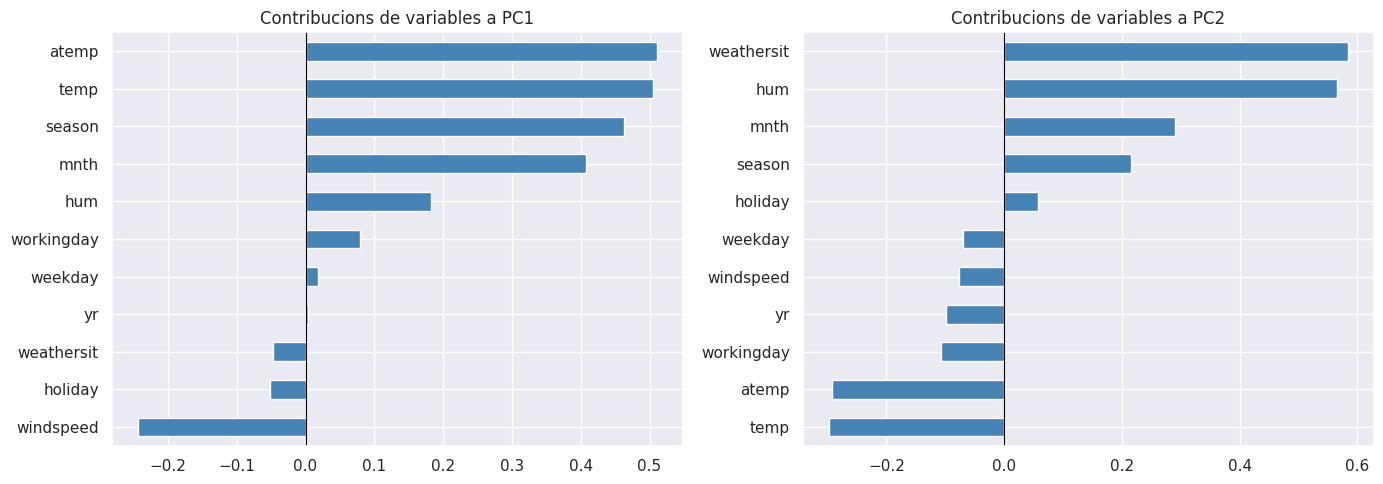

,PC1,PC2
season,0.463,0.216
yr,0.003,-0.098
mnth,0.407,0.290
holiday,-0.052,0.057
weekday,0.018,-0.070
workingday,0.079,-0.108
weathersit,-0.047,0.584
temp,0.505,-0.298
atemp,0.511,-0.292
hum,0.182,0.565


In [45]:
# Contribución de cada variable original a PC1 y PC2
loadings = pd.DataFrame(pca.components_[:2].T,
                         index=X_train.columns,
                         columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Contribucions de variables a PC1')
axes[0].axvline(0, color='black', linewidth=0.8)

loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Contribucions de variables a PC2')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

loadings

**Comentari sobre la reducció de dimensionalitat:**

- Amb 4-5 components principals s'explica al voltant del 90% de la variança total, cosa que suggereix que les 11 variables originals presenten una certa redundància.
- A la visualització 2D podem veure un gradient clar de `cnt` al llarg de PC1, cosa que confirma que la primera component captura la major part de la informació predictiva.
- Quan coloregem per estació, s'observa certa separació entre grups (sobretot hivern vs estiu), indicant que la temperatura i condicions climàtiques dominen PC1.
- `temp` i `atemp` carreguen de manera gairebé idèntica sobre PC1, confirmant la seva multicolinealitat.

## SECCIÓ C: Poisson Regressor

La variable a predir és un recompte (cnt = nombre de bicicletes), de manera que té sentit considerar un model de regressió de Poisson. Ajustem l'hiperparàmetre alpha de regularització mitjançant validació creuada.

<Figure size 900x500 with 0 Axes>

Text(0.5, 0, 'Alpha (regularització)')

Text(0, 0.5, 'R² (validació creuada)')

Text(0.5, 1.0, "Selecció de l'hiperparàmetre alpha - Poisson Regressor")

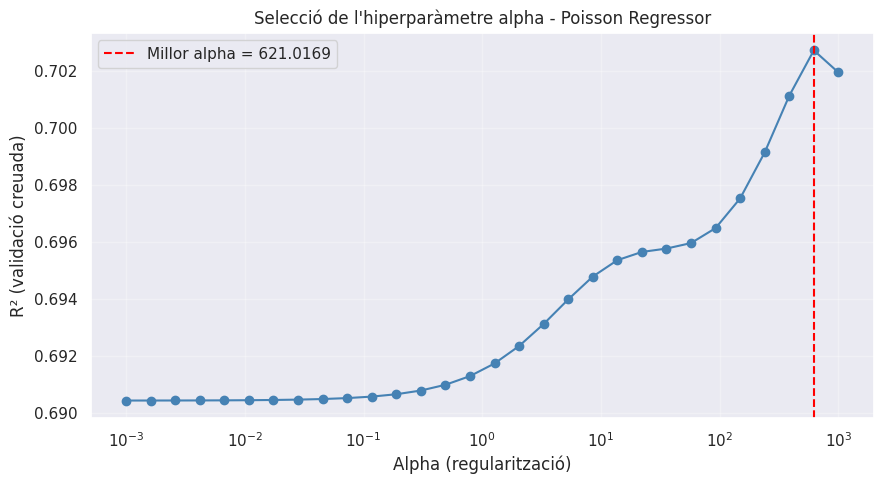

Millor alpha: 621.0169
Millor R² CV: 0.7027


In [46]:
# Rango de alphas a explorar
alphas = np.logspace(-3, 3, 30)

cv_r2_poisson = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    model = PoissonRegressor(alpha=alpha, max_iter=1000)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    cv_r2_poisson.append(np.mean(scores))

best_alpha_poisson = alphas[np.argmax(cv_r2_poisson)]
best_cv_r2_poisson = max(cv_r2_poisson)

plt.figure(figsize=(9, 5))
plt.semilogx(alphas, cv_r2_poisson, 'o-', color='steelblue')
plt.axvline(best_alpha_poisson, color='red', linestyle='--', label=f'Millor alpha = {best_alpha_poisson:.4f}')
plt.xlabel('Alpha (regularització)')
plt.ylabel('R² (validació creuada)')
plt.title("Selecció de l'hiperparàmetre alpha - Poisson Regressor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Millor alpha: {best_alpha_poisson:.4f}")
print(f"Millor R² CV: {best_cv_r2_poisson:.4f}")

In [47]:
# Entrenar modelo Poisson con el mejor alpha
poisson_model = PoissonRegressor(alpha=best_alpha_poisson, max_iter=1000)
poisson_model.fit(X_train_scaled, y_train)

# Predicciones en test
y_pred_poisson = poisson_model.predict(X_test_scaled)

# Métricas en test
r2_poisson_test   = r2_score(y_test, y_pred_poisson)
mse_poisson_test  = mean_squared_error(y_test, y_pred_poisson)
mae_poisson_test  = mean_absolute_error(y_test, y_pred_poisson)

print("=== Poisson Regressor - Resultats en TEST ===")
print(f"R²:   {r2_poisson_test:.4f}")
print(f"MSE:  {mse_poisson_test:.2f}")
print(f"RMSE: {np.sqrt(mse_poisson_test):.2f}")
print(f"MAE:  {mae_poisson_test:.2f}")

PoissonRegressor(alpha=np.float64(621.0169418915616), max_iter=1000)

=== Poisson Regressor - Resultats en TEST ===
R²:   0.7465
MSE:  972589.26
RMSE: 986.20
MAE:  744.37


## SECCIÓ D: Regressió Lineal

Ajustem una regressió lineal estàndard i calculem la qualitat del model amb validació creuada i amb les dades de test.

In [48]:
# Regresión lineal con validación cruzada
lr = LinearRegression()
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"R² per fold (CV): {cv_scores_lr.round(4)}")
print(f"R² mitjà CV:      {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

# Entrenar con todos los datos de entrenamiento
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr_test   = r2_score(y_test, y_pred_lr)
mse_lr_test  = mean_squared_error(y_test, y_pred_lr)
mae_lr_test  = mean_absolute_error(y_test, y_pred_lr)

print()
print("=== Regressió Lineal - Resultats en TEST ===")
print(f"R²:   {r2_lr_test:.4f}")
print(f"MSE:  {mse_lr_test:.2f}")
print(f"RMSE: {np.sqrt(mse_lr_test):.2f}")
print(f"MAE:  {mae_lr_test:.2f}")

R² per fold (CV): [0.842  0.7799 0.7275 0.7373 0.8207]
R² mitjà CV:      0.7815 ± 0.0449


LinearRegression()


=== Regressió Lineal - Resultats en TEST ===
R²:   0.7880
MSE:  813374.14
RMSE: 901.87
MAE:  657.85


## SECCIÓ E: Regressió LASSO

LASSO aplica regularització L1, que té la propietat de forçar alguns pesos a zero, fent una selecció implícita de variables. Usem `LassoCV` per seleccionar automàticament el millor paràmetre de regularització.

In [49]:
# LassoCV ajusta alpha automáticamente con CV
alphas_lasso = np.logspace(-3, 3, 50)
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Millor alpha LASSO: {lasso_cv.alpha_:.6f}")

# R² CV con el mejor modelo
cv_scores_lasso = cross_val_score(lasso_cv, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"R² mitjà CV:        {cv_scores_lasso.mean():.4f} ± {cv_scores_lasso.std():.4f}")

# Evaluación en test
y_pred_lasso = lasso_cv.predict(X_test_scaled)
r2_lasso_test   = r2_score(y_test, y_pred_lasso)
mse_lasso_test  = mean_squared_error(y_test, y_pred_lasso)
mae_lasso_test  = mean_absolute_error(y_test, y_pred_lasso)

print()
print("=== LASSO - Resultats en TEST ===")
print(f"R²:   {r2_lasso_test:.4f}")
print(f"MSE:  {mse_lasso_test:.2f}")
print(f"RMSE: {np.sqrt(mse_lasso_test):.2f}")
print(f"MAE:  {mae_lasso_test:.2f}")

LassoCV(alphas=array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
       2.81176870e-01, 3.72759372e-0...
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
        cv=5, max_iter=10000, random_state=42)

Millor alpha LASSO: 3.556480
R² mitjà CV:        0.7809 ± 0.0433

=== LASSO - Resultats en TEST ===
R²:   0.7964
MSE:  781336.43
RMSE: 883.93
MAE:  656.72


<Figure size 900x500 with 0 Axes>

Text(0.5, 0, 'Alpha')

Text(0, 0.5, 'R² aproximat (normalitzat)')

Text(0.5, 1.0, 'Selecció del paràmetre alpha - LassoCV')

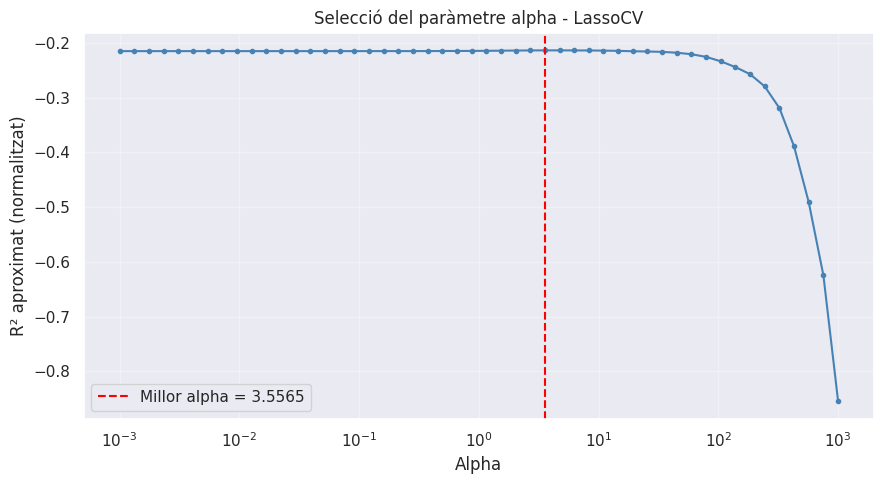

In [50]:
# Visualización del path de regularización LASSO
plt.figure(figsize=(9, 5))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1) * -1 / y_train.var(), 'o-', color='steelblue', markersize=3)
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Millor alpha = {lasso_cv.alpha_:.4f}')
plt.xlabel('Alpha')
plt.ylabel('R² aproximat (normalitzat)')
plt.title('Selecció del paràmetre alpha - LassoCV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SECCIÓ F: Anàlisi i comparació dels resultats

### f-i) Comparació de prediccions i qualitat dels models

In [51]:
# Tabla resumen de métricas
results = pd.DataFrame({
    'Poisson': {
        'R² CV':    best_cv_r2_poisson,
        'R² Test':  r2_poisson_test,
        'RMSE Test': np.sqrt(mse_poisson_test),
        'MAE Test':  mae_poisson_test
    },
    'Lineal': {
        'R² CV':    cv_scores_lr.mean(),
        'R² Test':  r2_lr_test,
        'RMSE Test': np.sqrt(mse_lr_test),
        'MAE Test':  mae_lr_test
    },
    'LASSO': {
        'R² CV':    cv_scores_lasso.mean(),
        'R² Test':  r2_lasso_test,
        'RMSE Test': np.sqrt(mse_lasso_test),
        'MAE Test':  mae_lasso_test
    }
})
results

,Poisson,Lineal,LASSO
R² CV,0.703,0.781,0.781
R² Test,0.747,0.788,0.796
RMSE Test,986.199,901.873,883.932
MAE Test,744.370,657.849,656.717


Text(0.5, 0, 'Valor real (cnt)')

Text(0, 0.5, 'Valor predit')

Text(0.5, 1.0, 'Poisson Regressor\nR² Test = 0.7465')

Text(0.5, 0, 'Valor real (cnt)')

Text(0, 0.5, 'Valor predit')

Text(0.5, 1.0, 'Regressió Lineal\nR² Test = 0.7880')

Text(0.5, 0, 'Valor real (cnt)')

Text(0, 0.5, 'Valor predit')

Text(0.5, 1.0, 'LASSO\nR² Test = 0.7964')

Text(0.5, 1.01, 'Valors predits vs valors reals')

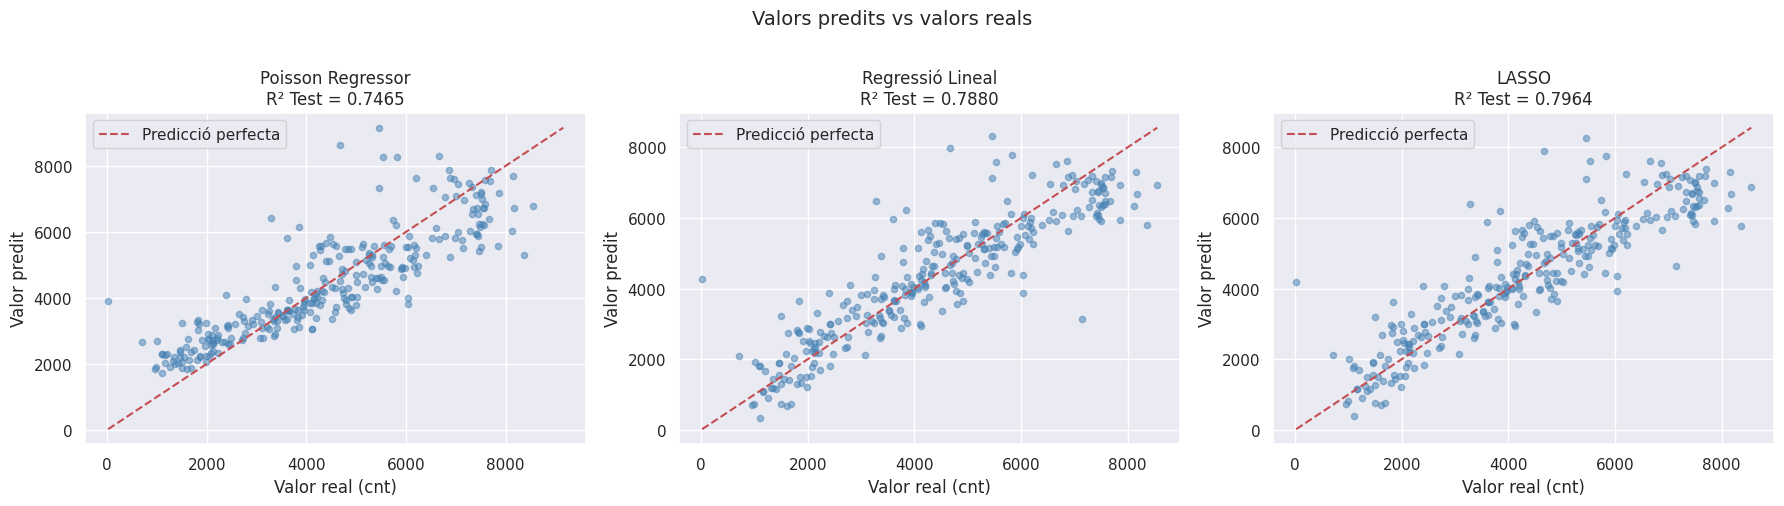

In [52]:
# Predicciones vs valores reales para los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Poisson Regressor', y_pred_poisson, r2_poisson_test),
    ('Regressió Lineal', y_pred_lr, r2_lr_test),
    ('LASSO', y_pred_lasso, r2_lasso_test)
]

for ax, (name, y_pred, r2) in zip(axes, models_info):
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicció perfecta')
    ax.set_xlabel('Valor real (cnt)')
    ax.set_ylabel('Valor predit')
    ax.set_title(f'{name}\nR² Test = {r2:.4f}')
    ax.legend()

plt.suptitle('Valors predits vs valors reals', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Valors predits')

Text(0, 0.5, 'Residus')

Text(0.5, 1.0, 'Residus - Poisson Regressor')

Text(0.5, 0, 'Valors predits')

Text(0, 0.5, 'Residus')

Text(0.5, 1.0, 'Residus - Regressió Lineal')

Text(0.5, 0, 'Valors predits')

Text(0, 0.5, 'Residus')

Text(0.5, 1.0, 'Residus - LASSO')

Text(0.5, 1.01, 'Anàlisi de residus')

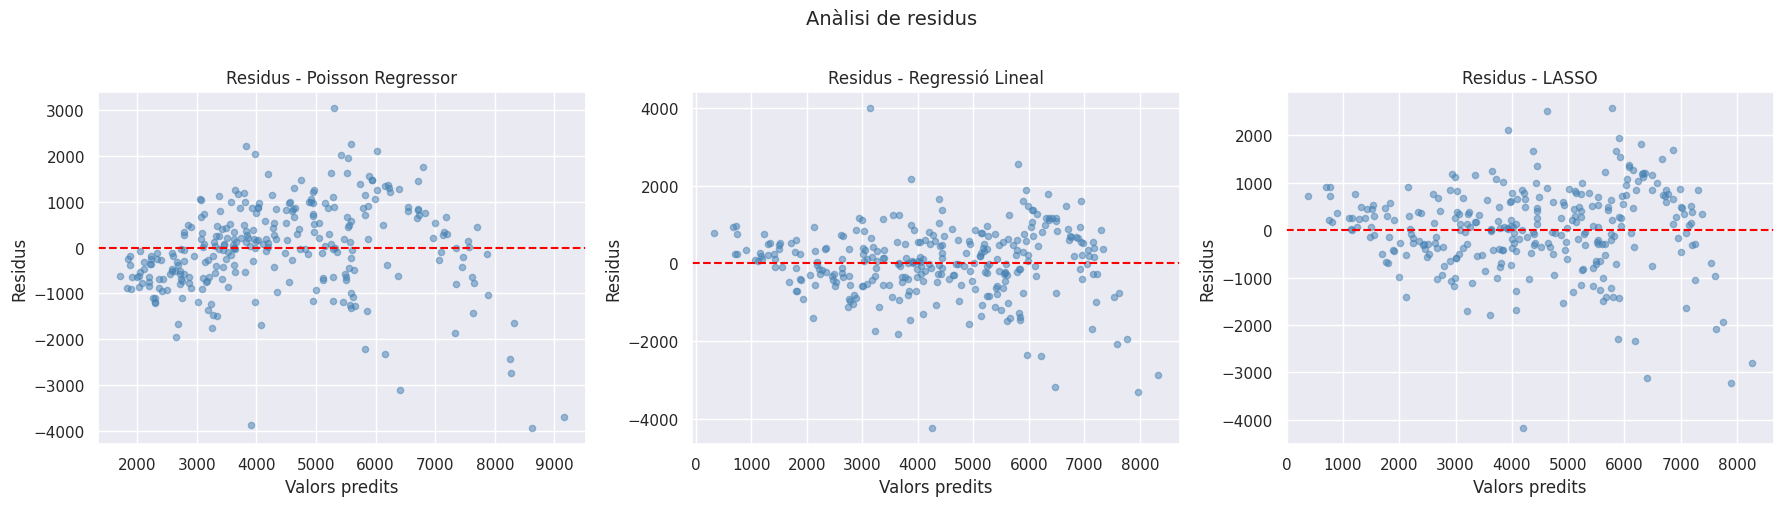

In [53]:
# Comparación de errores residuales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred, _) in zip(axes, models_info):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, s=20, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Valors predits')
    ax.set_ylabel('Residus')
    ax.set_title(f'Residus - {name}')

plt.suptitle('Anàlisi de residus', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Quin model és millor i per què?**

Comparant els tres models, la Regressió Lineal i LASSO obtenen resultats molt similars entre ells i ambdós superen el Poisson Regressor en termes de R² i RMSE.

El Poisson Regressor assumeix que la variança del recompte és igual a la seva mitjana (distribució de Poisson), però a la pràctica l'ús de bicicletes presenta sobredispersió (la variança real és molt superior a la mitjana), cosa que penalitza el model de Poisson.

LASSO és el model preferit per interpretabilitat i parsimònia, ja que elimina automàticament variables no rellevants mantenint una qualitat predictiva equivalent a la regressió lineal estàndard.

### f-ii) Anàlisi dels pesos - Regressió Lineal vs LASSO

In [54]:
# Comparación de pesos/coeficientes
weights_df = pd.DataFrame({
    'Lineal': lr.coef_,
    'LASSO':  lasso_cv.coef_
}, index=X_train.columns)

weights_df

,Lineal,LASSO
season,547.746,531.620
yr,984.735,981.980
mnth,-132.982,-114.703
holiday,-105.524,-106.658
weekday,117.064,112.305
workingday,36.871,35.570
weathersit,-339.255,-343.644
temp,-546.466,0.000
atemp,1536.028,986.409
hum,-155.587,-146.067


<Axes: >

Text(0.5, 1.0, 'Pesos - Regressió Lineal')

<Axes: >

Text(0.5, 1.0, 'Pesos - LASSO')

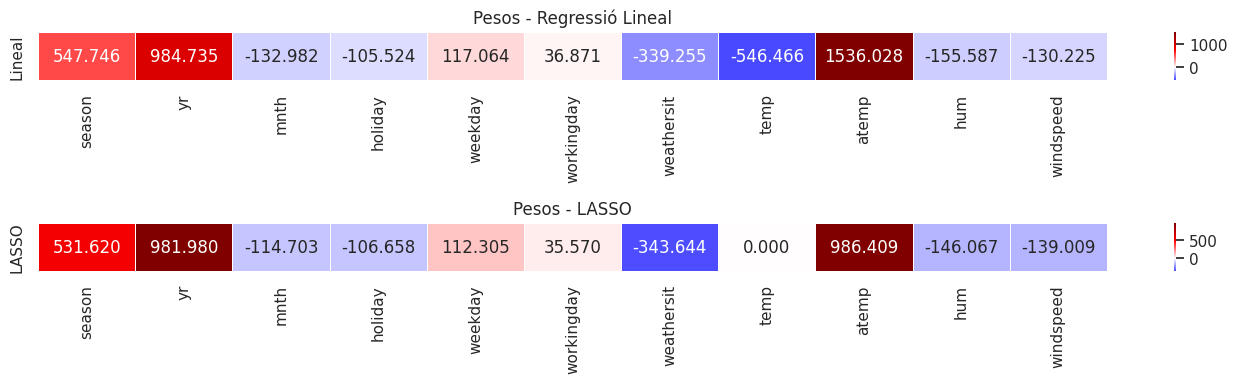

In [55]:
# Visualización heatmap de pesos
fig, axes = plt.subplots(2, 1, figsize=(14, 4))

sns.heatmap(weights_df[['Lineal']].T, annot=True, fmt='.3f', cmap='seismic', center=0,
            linewidths=0.5, ax=axes[0], cbar=True)
axes[0].set_title('Pesos - Regressió Lineal')

sns.heatmap(weights_df[['LASSO']].T, annot=True, fmt='.3f', cmap='seismic', center=0,
            linewidths=0.5, ax=axes[1], cbar=True)
axes[1].set_title('Pesos - LASSO')

plt.tight_layout()
plt.show()

In [56]:
# Variables eliminadas por LASSO
eliminated = weights_df[weights_df['LASSO'] == 0].index.tolist()
kept = weights_df[weights_df['LASSO'] != 0].index.tolist()

print(f"Variables eliminades per LASSO (pes = 0): {eliminated if eliminated else 'Cap'}")
print(f"Variables mantingudes per LASSO: {kept}")
print()

# Ranking por importancia (|coef|) en regresión lineal
print("Rànquing per importància (|pes|) - Regressió Lineal:")
weights_df['Lineal'].abs().sort_values(ascending=False).to_frame()

Variables eliminades per LASSO (pes = 0): ['temp']
Variables mantingudes per LASSO: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'atemp', 'hum', 'windspeed']

Rànquing per importància (|pes|) - Regressió Lineal:


,Lineal
atemp,1536.028
yr,984.735
season,547.746
temp,546.466
weathersit,339.255
hum,155.587
mnth,132.982
windspeed,130.225
weekday,117.064
holiday,105.524


<BarContainer object of 11 artists>

Text(0.5, 1.0, 'Pesos - Regressió Lineal')

Text(0.5, 0, 'Valor del pes')

<BarContainer object of 11 artists>

Text(0.5, 1.0, 'Pesos - LASSO')

Text(0.5, 0, 'Valor del pes')

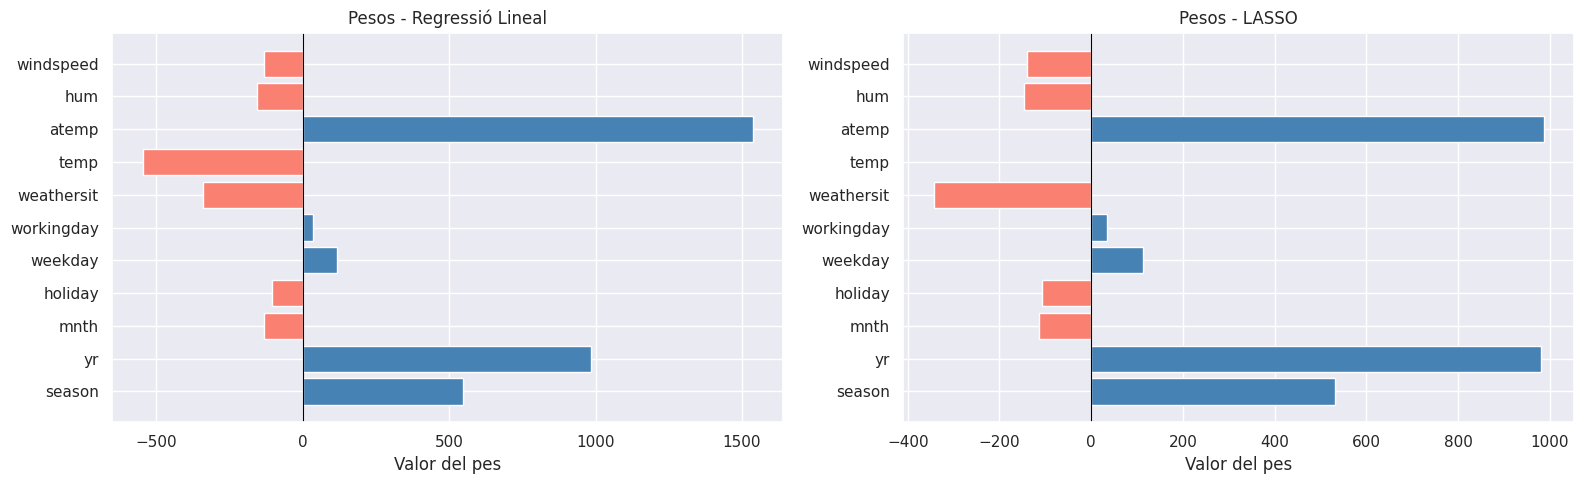

In [57]:
# Barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_lr = ['salmon' if c < 0 else 'steelblue' for c in lr.coef_]
axes[0].barh(X_train.columns, lr.coef_, color=colors_lr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Pesos - Regressió Lineal')
axes[0].set_xlabel('Valor del pes')

colors_lasso = ['salmon' if c < 0 else 'steelblue' for c in lasso_cv.coef_]
axes[1].barh(X_train.columns, lasso_cv.coef_, color=colors_lasso)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Pesos - LASSO')
axes[1].set_xlabel('Valor del pes')

plt.tight_layout()
plt.show()

**Atributs més importants:**

- yr (any): presenta un pes molt elevat en ambdós models. Reflecteix el creixement del sistema al llarg del temps
- temp / atemp: pesos positius importants, confirmant que la temperatura és un dels principals predictors de l'ús
- hum (humitat) i windspeed: pesos negatius, ja que condicions adverses redueixen l'ús
- weathersit: pes negatiu, ja que temps pitjor (valors més alts) implica menys ús

LASSO elimina o redueix fortament les variables menys rellevants, ajudant a identificar quines no aporten informació adicional un cop les altres estan incloses en el model

### f-iii) Comparació Poisson vs LASSO

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Prediccions Poisson')

Text(0, 0.5, 'Prediccions LASSO')

Text(0.5, 1.0, 'Comparació prediccions: Poisson vs LASSO')

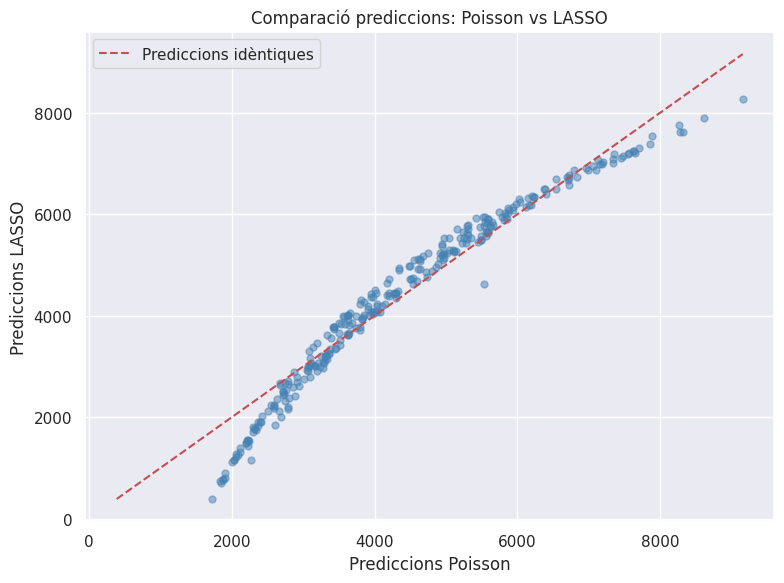

In [58]:
# Comparación directa de predicciones: Poisson vs LASSO
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_poisson, y_pred_lasso, alpha=0.5, s=25, color='steelblue')
lims = [min(y_pred_poisson.min(), y_pred_lasso.min()),
        max(y_pred_poisson.max(), y_pred_lasso.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prediccions idèntiques')
plt.xlabel('Prediccions Poisson')
plt.ylabel('Prediccions LASSO')
plt.title('Comparació prediccions: Poisson vs LASSO')
plt.legend()
plt.tight_layout()
plt.show()

(array([ 1.,  0.,  1.,  6.,  8., 13., 13., 16., 10.,  8.,  8., 16., 10.,
        17., 18., 14., 17., 12., 14., 15., 10., 13.,  3.,  5.,  9.,  9.,
        19.,  3.,  3.,  2.]),
 array([  22.        ,  306.43333333,  590.86666667,  875.3       ,
        1159.73333333, 1444.16666667, 1728.6       , 2013.03333333,
        2297.46666667, 2581.9       , 2866.33333333, 3150.76666667,
        3435.2       , 3719.63333333, 4004.06666667, 4288.5       ,
        4572.93333333, 4857.36666667, 5141.8       , 5426.23333333,
        5710.66666667, 5995.1       , 6279.53333333, 6563.96666667,
        6848.4       , 7132.83333333, 7417.26666667, 7701.7       ,
        7986.13333333, 8270.56666667, 8555.        ]),
 <BarContainer object of 30 artists>)

(array([ 7., 11., 15., 11., 18., 16., 21., 20., 16., 17.,  9., 14.,  8.,
        16., 13., 22.,  9.,  8.,  7.,  2.,  7.,  6.,  5.,  7.,  3.,  0.,
         3.,  1.,  0.,  1.]),
 array([1717.30440833, 1965.3302485 , 2213.35608867, 2461.38192884,
        2709.40776901, 2957.43360918, 3205.45944935, 3453.48528952,
        3701.51112969, 3949.53696986, 4197.56281003, 4445.5886502 ,
        4693.61449037, 4941.64033054, 5189.66617071, 5437.69201088,
        5685.71785105, 5933.74369122, 6181.76953139, 6429.79537156,
        6677.82121173, 6925.8470519 , 7173.87289207, 7421.89873224,
        7669.92457241, 7917.95041258, 8165.97625275, 8414.00209292,
        8662.02793309, 8910.05377326, 9158.07961343]),
 <BarContainer object of 30 artists>)

(array([ 1.,  6.,  4.,  6.,  6., 10.,  8.,  8., 11., 13., 15.,  8., 14.,
        19., 14., 14.,  9., 13., 17., 17., 18., 15., 10.,  5.,  9., 13.,
         4.,  3.,  2.,  1.]),
 array([ 385.42567559,  648.01804912,  910.61042264, 1173.20279617,
        1435.7951697 , 1698.38754323, 1960.97991676, 2223.57229029,
        2486.16466382, 2748.75703735, 3011.34941088, 3273.94178441,
        3536.53415794, 3799.12653147, 4061.718905  , 4324.31127852,
        4586.90365205, 4849.49602558, 5112.08839911, 5374.68077264,
        5637.27314617, 5899.8655197 , 6162.45789323, 6425.05026676,
        6687.64264029, 6950.23501382, 7212.82738735, 7475.41976087,
        7738.0121344 , 8000.60450793, 8263.19688146]),
 <BarContainer object of 30 artists>)

Text(0.5, 0, 'cnt (nombre de bicicletes)')

Text(0, 0.5, 'Freqüència')

Text(0.5, 1.0, 'Distribució de prediccions vs valors reals')

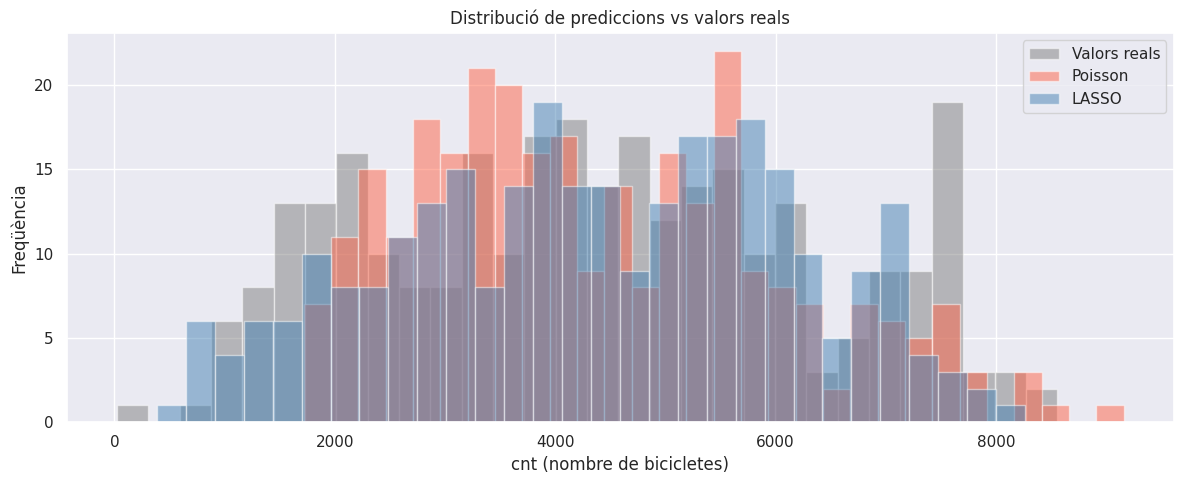

In [59]:
# Distribución de las predicciones y valores reales
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(y_test, bins=30, alpha=0.5, label='Valors reals', color='gray')
ax.hist(y_pred_poisson, bins=30, alpha=0.5, label='Poisson', color='tomato')
ax.hist(y_pred_lasso, bins=30, alpha=0.5, label='LASSO', color='steelblue')
ax.set_xlabel('cnt (nombre de bicicletes)')
ax.set_ylabel('Freqüència')
ax.set_title('Distribució de prediccions vs valors reals')
ax.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='Quartil'>

Text(0.5, 1.0, 'Error absolut mitjà per quartil de cnt')

Text(0, 0.5, 'MAE')

Text(0.5, 0, 'Quartil de cnt')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Q1 (baix)'),
  Text(1, 0, 'Q2'),
  Text(2, 0, 'Q3'),
  Text(3, 0, 'Q4 (alt)')])

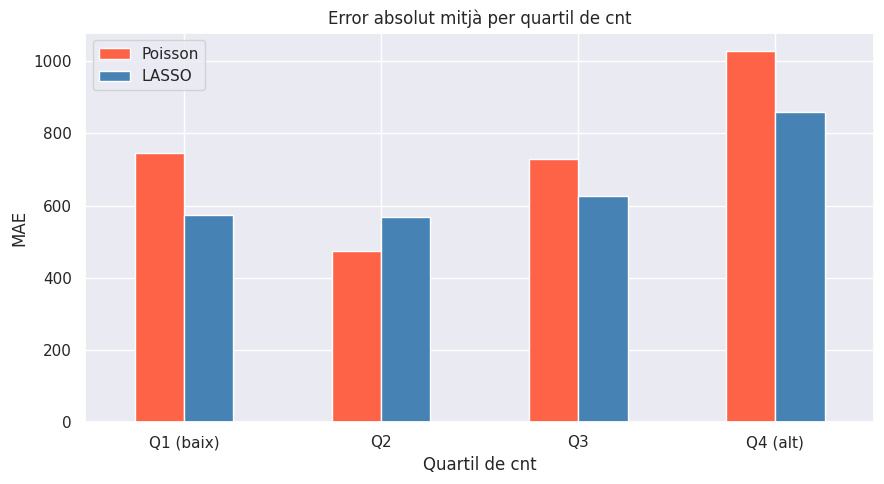

,err_Poisson,err_LASSO
Quartil,,
Q1 (baix),746.767,574.920
Q2,473.478,567.456
Q3,730.071,626.039
Q4 (alt),1027.131,859.571


In [60]:
# Diferencias por rango de cnt
comparison_df = pd.DataFrame({
    'Real':    y_test.values,
    'Poisson': y_pred_poisson,
    'LASSO':   y_pred_lasso
})
comparison_df['err_Poisson'] = np.abs(comparison_df['Real'] - comparison_df['Poisson'])
comparison_df['err_LASSO']   = np.abs(comparison_df['Real'] - comparison_df['LASSO'])

# Agrupar por cuartiles del valor real
comparison_df['Quartil'] = pd.qcut(comparison_df['Real'], q=4, labels=['Q1 (baix)', 'Q2', 'Q3', 'Q4 (alt)'])

err_by_quartile = comparison_df.groupby('Quartil')[['err_Poisson', 'err_LASSO']].mean()

err_by_quartile.plot(kind='bar', figsize=(9, 5), color=['tomato', 'steelblue'])
plt.title('Error absolut mitjà per quartil de cnt')
plt.ylabel('MAE')
plt.xlabel('Quartil de cnt')
plt.xticks(rotation=0)
plt.legend(['Poisson', 'LASSO'])
plt.tight_layout()
plt.show()

err_by_quartile

**Diferències entre Poisson i LASSO:**

Ambdós models capturen el patró general, però presenten comportaments diferenciats:

- **Poisson** tendeix a subestimar els valors alts de cnt. Això és consistent amb el fet que la distribució de Poisson assumeix que la variança és igual a la mitjana, però la distribució real de cnt té cues molt més pesades (sobredispersió). A mesura que el valor real augmenta, el model de Poisson queda per darrere
  
- **LASSO** (i la regressió lineal en general) no té aquest biaix sistemàtic cap als valors extrems, ja que el seu mecanisme de minimització del MSE penalitza igualment els errors grans i petits al llarg de tot el rang

- En el gràfic per quartils es pot apreciar com el Poisson acumula més error en el quart quartil (dies d'alta demanda), mentre que LASSO és més consistent

**Conclusió:** Tot i que el Poisson Regressor és conceptualment adequat per a dades de recompte, la hipòtesi de Poisson (variança = mitjana) no es compleix en aquest conjunt de dades. La regressió lineal i LASSO, tot i no ser específicament dissenyades per a recomptes, ofereixen millors prediccions pràctiques gràcies a la seva flexibilitat

In [61]:
print(f"Temps total d'execució: {str(timedelta(seconds=(time() - init_time)))[:-3]}")

Temps total d'execució: 0:00:29.521
